# 📊 Análisis de Correlación Macroeconómica — Rentas Cedidas

**Componente de Tesis: Relación Recaudo vs Variables Exógenas**

Este notebook analiza la correlación entre el recaudo de rentas cedidas y las principales
variables macroeconómicas: IPC, Salario Mínimo y UPC (Unidad de Pago por Capitación).
El Índice de Eficiencia del Portafolio (IEP) mide si el recaudo crece más rápido que
la inflación del costo de la UPC.

---

In [1]:
import sys
sys.path.insert(0, '.')
sys.path.insert(0, '../scripts')
%run 00_config.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import cargar_datos, agregar_mensual, formato_pesos

  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
✅ Config cargada — Datos: BaseRentasVF_2022_2025.xlsx | Periodo: 2022-01-01 a 2025-12-31
  🎨 Tema profesional activo — DPI 300, tipografía serif, paleta académica


✅ Config cargada — Datos: BaseRentasVF_2022_2025.xlsx | Periodo: 2022-01-01 a 2025-12-31
  🎨 Tema profesional activo — DPI 300, tipografía serif, paleta académica


## 1. Preparación de Datos con Variables Macro

In [2]:
# 1.1 Cargar serie mensual
try:
    df_mensual = pd.read_csv(DATA_PROCESSED / 'serie_mensual.csv', index_col=0, parse_dates=True)
except FileNotFoundError:
    df = cargar_datos(DATA_FILE)
    df_mensual = agregar_mensual(df)

# 1.2 Agregar variables macroeconómicas desde config
df_mensual['Año'] = df_mensual.index.year
df_mensual['IPC'] = df_mensual['Año'].map(lambda y: MACRO_DATA.get(y, {}).get('IPC', np.nan))
df_mensual['Salario_Minimo'] = df_mensual['Año'].map(lambda y: MACRO_DATA.get(y, {}).get('Salario_Minimo', np.nan))
df_mensual['UPC'] = df_mensual['Año'].map(lambda y: MACRO_DATA.get(y, {}).get('UPC', np.nan))

# 1.3 Lag de 12 meses y variación interanual
df_mensual['lag_12'] = df_mensual['Recaudo_Neto'].shift(12)
df_mensual['YoY_Recaudo'] = (df_mensual['Recaudo_Neto'] / df_mensual['lag_12'] - 1) * 100

# 1.4 Índice de Eficiencia del Portafolio (IEP)
df_mensual['IEP'] = df_mensual['YoY_Recaudo'] / df_mensual['UPC']

df_mensual.dropna(inplace=True)
print(f'✅ Dataset con variables macro: {len(df_mensual)} meses')
df_mensual.head()

✅ Dataset con variables macro: 36 meses


,Recaudo_Neto,Año,IPC,Salario_Minimo,UPC,lag_12,YoY_Recaudo,IEP
FechaRecaudo,,,,,,,,
2023-01-01,3.713434e+11,2023,9.28,16.0,16.23,3.042593e+11,22.048351,1.358494
2023-02-01,1.900078e+11,2023,9.28,16.0,16.23,1.799829e+11,5.569931,0.343187
2023-03-01,3.635568e+11,2023,9.28,16.0,16.23,2.765862e+11,31.444320,1.937420
2023-04-01,1.616941e+11,2023,9.28,16.0,16.23,1.905671e+11,-15.151118,-0.933525
2023-05-01,2.001770e+11,2023,9.28,16.0,16.23,1.810644e+11,10.555715,0.650383


## 2. Matriz de Correlación

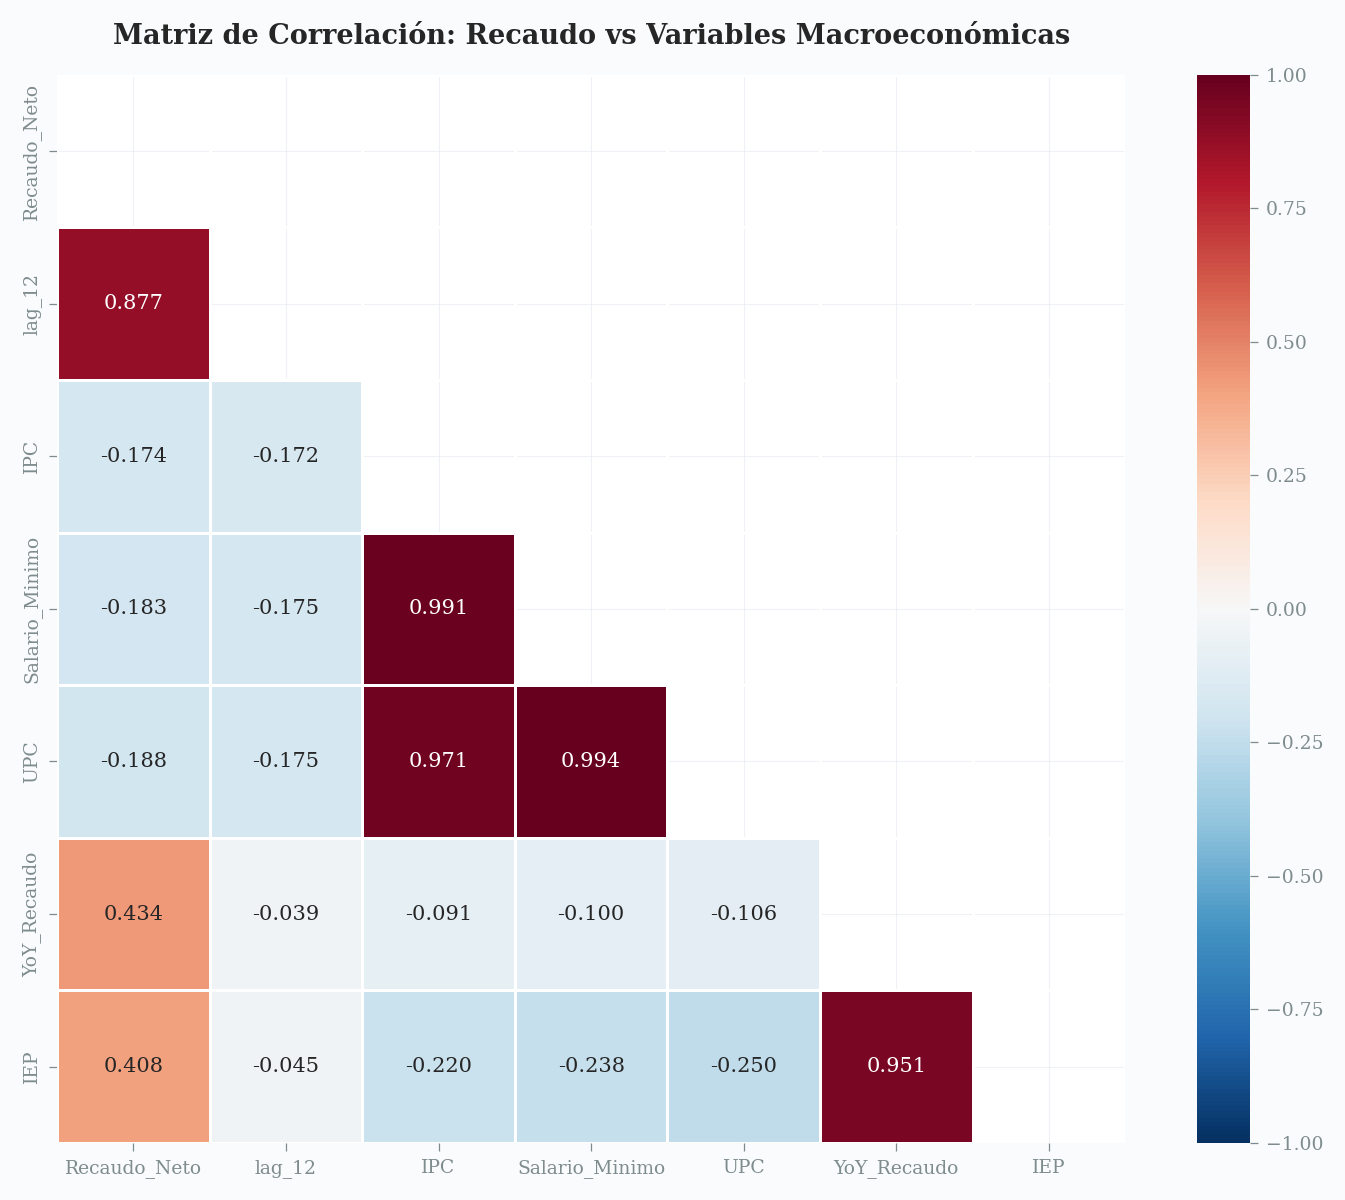


📊 Correlación con Recaudo_Neto:
                 lag_12: r = +0.877 (Fuerte)
                    IPC: r = -0.174 (Débil)
         Salario_Minimo: r = -0.183 (Débil)
                    UPC: r = -0.188 (Débil)
                    IEP: r = +0.408 (Moderada)


In [3]:
# 2.1 Correlación entre variables
cols_corr = ['Recaudo_Neto', 'lag_12', 'IPC', 'Salario_Minimo', 'UPC', 'YoY_Recaudo', 'IEP']
corr_matrix = df_mensual[cols_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlación: Recaudo vs Variables Macroeconómicas', fontweight='bold', fontsize=13)
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '03_matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen de correlaciones con recaudo
print('\n📊 Correlación con Recaudo_Neto:')
for col in ['lag_12', 'IPC', 'Salario_Minimo', 'UPC', 'IEP']:
    r = corr_matrix.loc['Recaudo_Neto', col]
    fuerza = 'Fuerte' if abs(r) > 0.7 else ('Moderada' if abs(r) > 0.4 else 'Débil')
    print(f'   {col:>20}: r = {r:+.3f} ({fuerza})')

## 3. Análisis de Dispersión

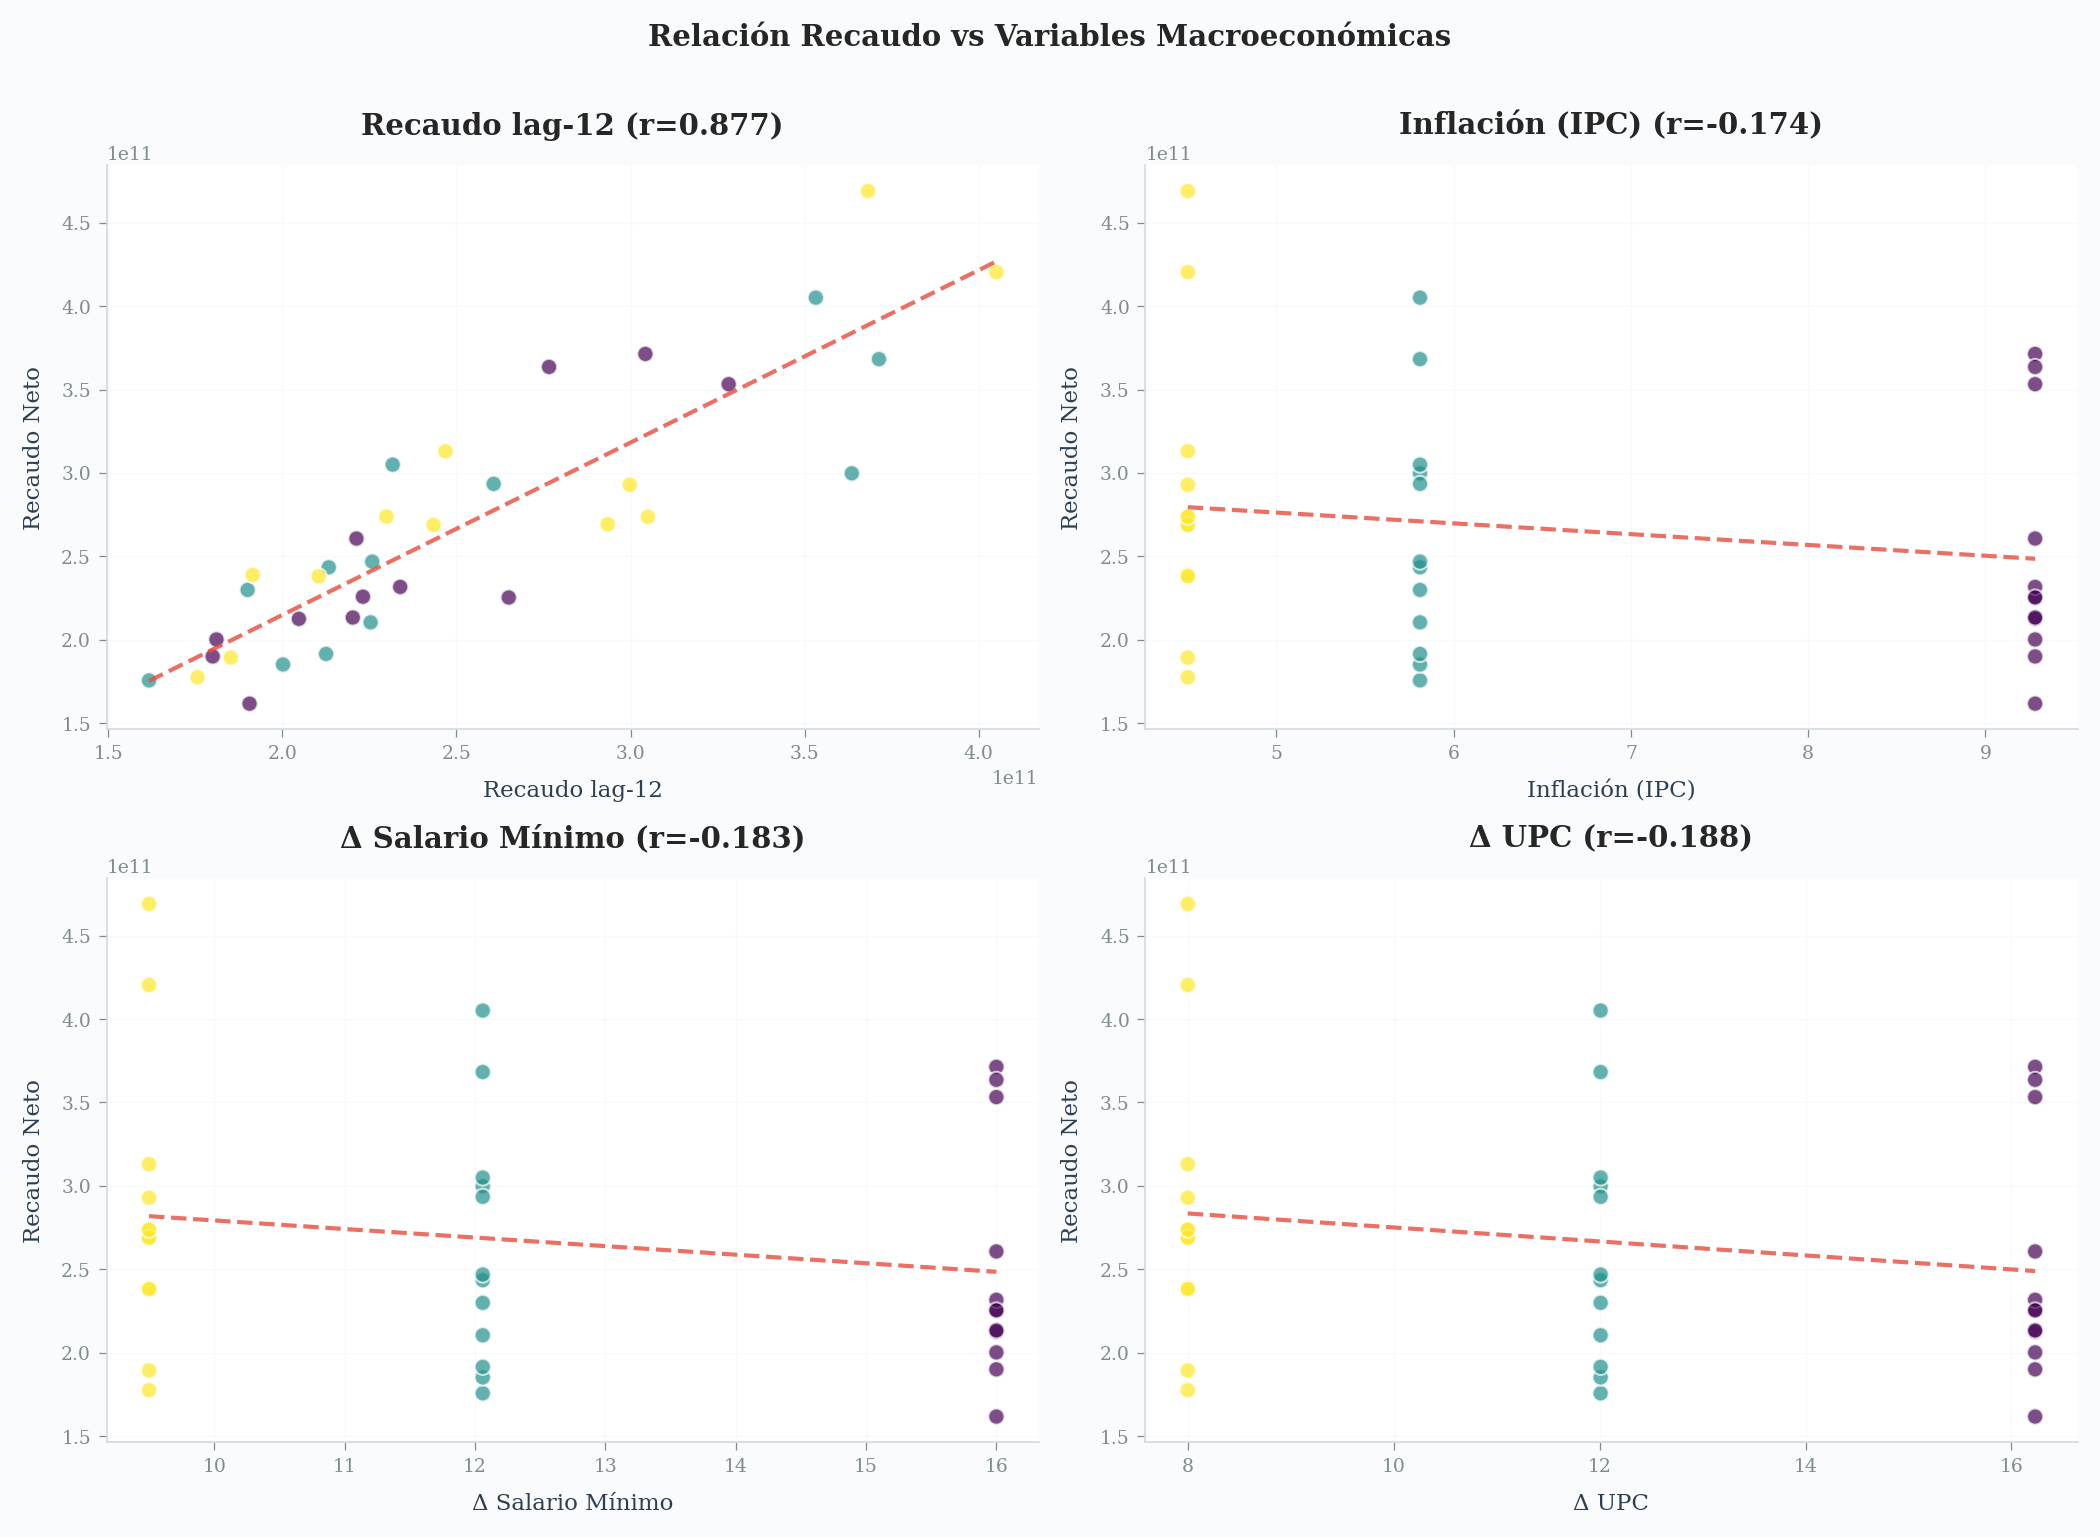

In [4]:
# 3.1 Scatter plots con regresión
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

vars_exo = [('lag_12', 'Recaudo lag-12'), ('IPC', 'Inflación (IPC)'), 
            ('Salario_Minimo', 'Δ Salario Mínimo'), ('UPC', 'Δ UPC')]

for ax, (col, titulo) in zip(axes.flat, vars_exo):
    ax.scatter(df_mensual[col], df_mensual['Recaudo_Neto'], 
               c=df_mensual.index.year, cmap='viridis', s=60, alpha=0.7, edgecolors='white')
    # Línea de tendencia
    z = np.polyfit(df_mensual[col].values, df_mensual['Recaudo_Neto'].values, 1)
    p = np.poly1d(z)
    x_range = np.linspace(df_mensual[col].min(), df_mensual[col].max(), 100)
    ax.plot(x_range, p(x_range), '--', color='#E74C3C', linewidth=2, alpha=0.8)
    
    r = df_mensual[[col, 'Recaudo_Neto']].corr().iloc[0,1]
    ax.set_title(f'{titulo} (r={r:.3f})', fontweight='bold')
    ax.set_xlabel(titulo)
    ax.set_ylabel('Recaudo Neto')
    ax.grid(True, alpha=0.3)

plt.suptitle('Relación Recaudo vs Variables Macroeconómicas', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '03_scatter_macro.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Índice de Eficiencia del Portafolio (IEP)


📊 IEP Promedio: 0.65
   Meses con IEP > 1 (eficiente): 14 / 36


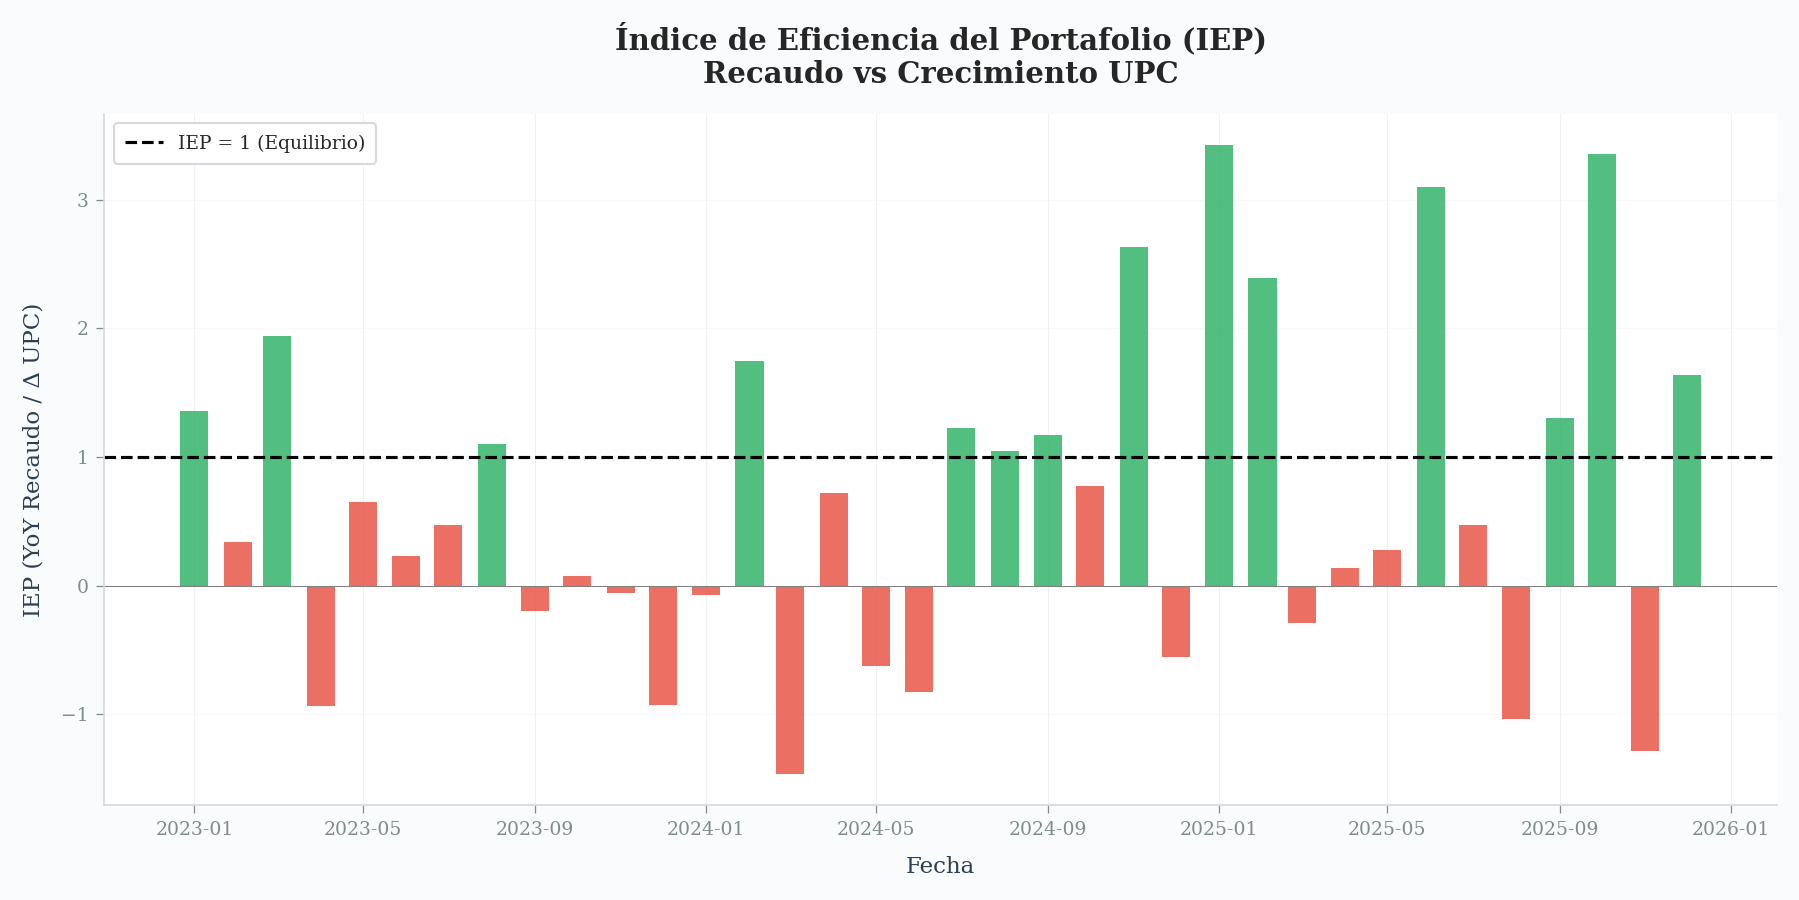


💾 Datos con variables macro exportados

  ✅ CORRELACIÓN MACRO COMPLETADA — Proceder con 04_SARIMA.ipynb


In [5]:
# 4.1 Serie temporal del IEP
fig, ax = plt.subplots(figsize=FIGSIZE_STANDARD)

colors_iep = ['#27AE60' if v > 1 else '#E74C3C' for v in df_mensual['IEP']]
ax.bar(df_mensual.index, df_mensual['IEP'], color=colors_iep, width=20, alpha=0.8)
ax.axhline(y=1, color='black', linewidth=1.5, linestyle='--', label='IEP = 1 (Equilibrio)')
ax.axhline(y=0, color='gray', linewidth=0.5)

ax.set_title('Índice de Eficiencia del Portafolio (IEP)\nRecaudo vs Crecimiento UPC', fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('IEP (YoY Recaudo / Δ UPC)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

iep_prom = df_mensual['IEP'].mean()
print(f'\n📊 IEP Promedio: {iep_prom:.2f}')
print(f'   Meses con IEP > 1 (eficiente): {(df_mensual["IEP"] > 1).sum()} / {len(df_mensual)}')

plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '03_iep_eficiencia.png', dpi=150, bbox_inches='tight')
plt.show()

# Exportar datos con features macro
df_mensual.to_csv(DATA_PROCESSED / 'serie_mensual_macro.csv')
print(f'\n💾 Datos con variables macro exportados')
print('\n' + '='*60)
print('  ✅ CORRELACIÓN MACRO COMPLETADA — Proceder con 04_SARIMA.ipynb')
print('='*60)